# Importing libraries

In [3]:
import torch
import cv2
import matplotlib.pyplot as plt

### Check if cuda is enabled For GPU acceleration

In [4]:
torch.cuda.is_available()
# torch.cuda.get_device_capability()
# torch.cuda.get_device_properties()

True

# Select MiDaS model size and Load model

In [ ]:
model_type = "DPT_Large"     # MiDaS v3 - Large     (highest accuracy, slowest inference speed)
#model_type = "DPT_Hybrid"   # MiDaS v3 - Hybrid    (medium accuracy, medium inference speed)
#model_type = "MiDaS_small"  # MiDaS v2.1 - Small   (lowest accuracy, highest inference speed)

midas = torch.hub.load("intel-isl/MiDaS", model_type)

### If cuda is present, move the model to GPU

In [6]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
midas.to(device)
midas.eval()

DPTDepthModel(
  (pretrained): Module(
    (model): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
    

### Loading MiDaS transforms

In [7]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type == "DPT_Large" or model_type == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

Using cache found in C:\Users\Ved Office/.cache\torch\hub\intel-isl_MiDaS_master


# Loading Room image in CV2

In [8]:
filename = '../images/room2.jpg'

In [169]:
img = cv2.imread(filename)
# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

### Getting inverse depth values using MiDaS

MiDaS is used to get apparent depth values inside an image

In [10]:
with torch.no_grad():
    prediction = midas(input_batch)

    prediction1 = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

# unsized_out = prediction.cpu().numpy()
output = prediction1.cpu().numpy()

### Comparing original image to depth map

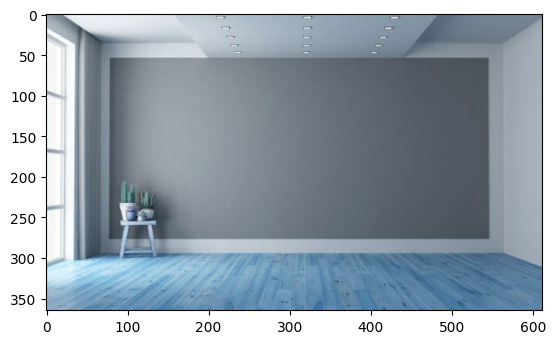

In [89]:
plt.imshow(img)

### Checking value ranges

In [12]:
output.max(), output.min(), output.mean()

(np.float32(32.492546), np.float32(5.6745067), np.float32(12.371377))

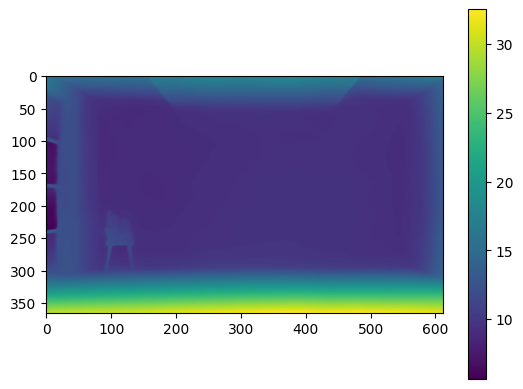

In [13]:
im = plt.imshow(output)
plt.colorbar(im)
plt.show()

Since depth map is inverse, higher the value, closer the object to us in the image

# Loading SAM model

SAM is Segment Anything Model used to find out individual segments inside images which can be objects or portions of objects or structures

In [14]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import cv2
import numpy as np

In [15]:
device

device(type='cuda')

### Creating auto segmenter for masking objects in the room and getting their mask boxes and additional values such as areas

In [16]:
sam = sam_model_registry["default"](checkpoint="checkpoints/sam_vit_h_4b8939.pth")
sam = sam.to(device=device)
mask_gen = SamAutomaticMaskGenerator(sam)

In [17]:
mask_gen

### Function to color code masks

In [18]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

## Loading chair image and applying SAM on it

In [19]:
chair_image = cv2.imread("../images/chair.jpg")
# chair_image = cv2.cvtColor(chair_image, cv2.COLOR_BGR2RGB)

In [20]:
chair_masks = mask_gen.generate(chair_image)

In [ ]:
chair_masks

In [187]:
type(chair_masks[0]['segmentation'])

numpy.ndarray

### Comparing og image to segmented

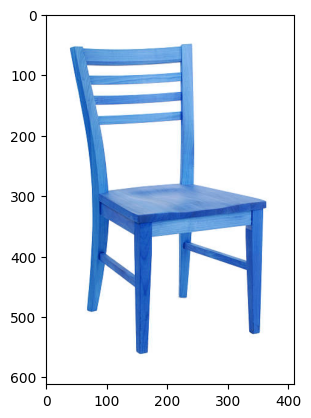

In [22]:
plt.imshow(chair_image)

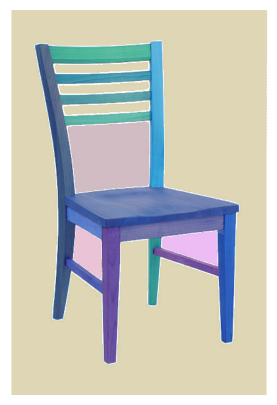

In [23]:
plt.figure(figsize=(5,5))
plt.imshow(chair_image)
show_anns(chair_masks)
plt.axis('off')
plt.show()

## Applying SAM to room image

In [24]:
room_masks = mask_gen.generate(img)

### Comparing original room image to segmented

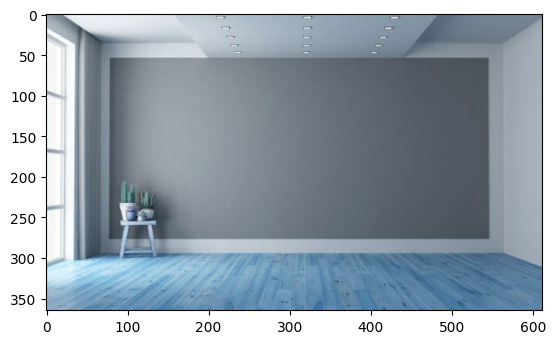

In [25]:
plt.imshow(img)

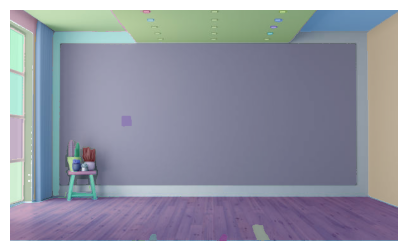

In [26]:
plt.figure(figsize=(5,5))
plt.imshow(img)
show_anns(room_masks)
plt.axis('off')
plt.show() 

## Get masks ordered by area

In [27]:
sorted_masks = sorted(room_masks, key=(lambda x: x['area']), reverse=True)
sorted_masks

[{'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]], shape=(365, 612)),
  'area': 100751,
  'bbox': [78, 54, 468, 222],
  'predicted_iou': 1.0357521772384644,
  'point_coords': [[525.9375, 119.765625]],
  'stability_score': 0.9883400797843933,
  'crop_box': [0, 0, 612, 365]},
 {'segmentation': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [False, False, False, ..., False, False, False]], shape=(365, 612)),

# Get best mask by trying different objects

In [28]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2)) 

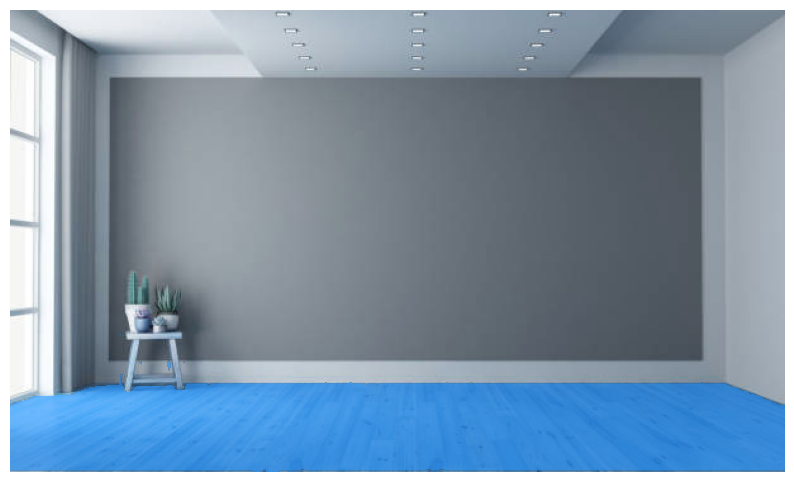

In [29]:
plt.figure(figsize=(10,10))
plt.imshow(img)
show_mask(sorted_masks[1]['segmentation'], plt.gca())
plt.axis('off')
plt.show() 

In [ ]:
best_mask = sorted_masks[1]
best_mask

Wall is good reference point

## Scaling values down between 0 and 1

In [31]:
from sklearn.preprocessing import MinMaxScaler

In [32]:
scaler = MinMaxScaler()
scaled_depth = scaler.fit_transform(output)

### extracting height and width of boundary box for ref

In [33]:
x, y, w, h = best_mask['bbox']

In [34]:
h, w, x, y

(109, 611, 0, 255)

## Calculating pixels per meter for the reference object (wall here)

In [35]:
real_wall_width = 5
real_wall_heigth = 0.75 # in meters (user input)

In [36]:
ppm_w = w / real_wall_width  # pixels per meter
ppm_h = h / real_wall_heigth
ppm_w, ppm_h

(122.2, 145.33333333333334)

### Selecting a random reference point to get depth at that reference spot

In [37]:
ref_point = (x + w//2, y + h//2)  # selecting a random point inside bounding box
M_ref = output[ref_point]
M_ref, ref_point # depth at the center of the bounding box

(np.float32(13.955831), (305, 309))

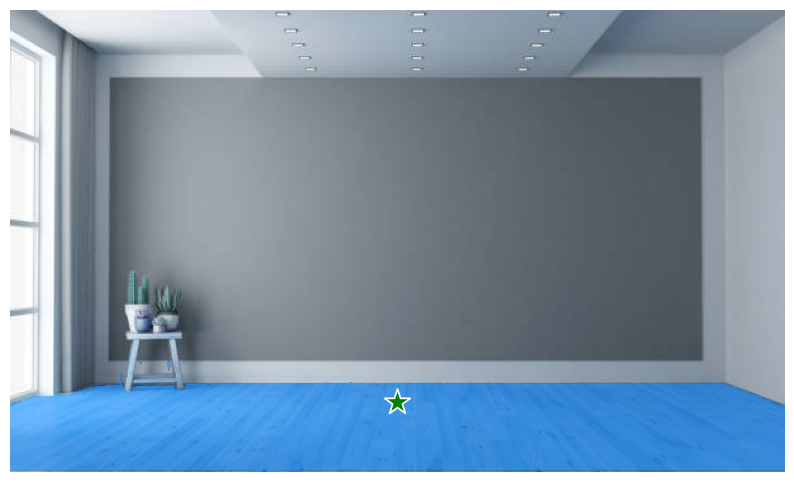

In [38]:
plt.figure(figsize=(10,10))
plt.imshow(img)
show_mask(sorted_masks[1]['segmentation'], plt.gca())
show_points(np.array([ref_point]), np.array([1]), plt.gca())
plt.axis('off')
plt.show()

### Selecting a spot to place our chair and getting the depth value at that place

In [39]:
place_point = (300, 260)
M_place = output[place_point]
M_place

np.float32(12.243162)

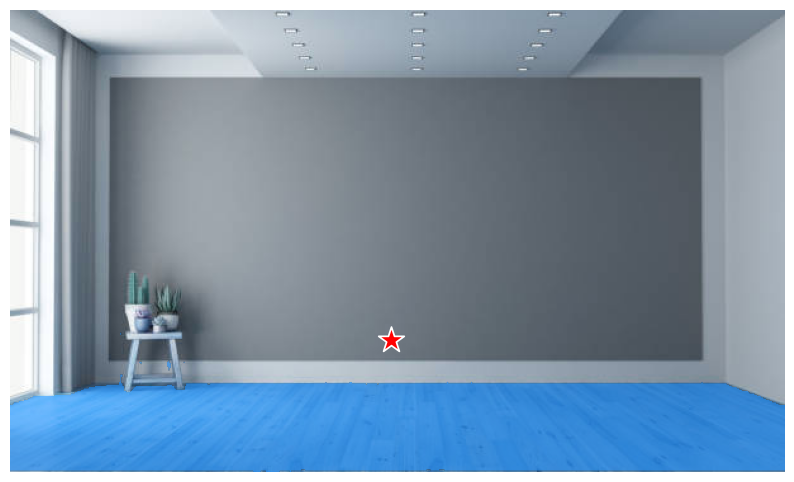

In [40]:
plt.figure(figsize=(10,10))
plt.imshow(img)
show_mask(sorted_masks[1]['segmentation'], plt.gca())
show_points(np.array([place_point]), np.array([0]), plt.gca())
plt.axis('off')
plt.show()

In [41]:
scaled_depth.shape

(365, 612)

In [42]:
np.min(scaled_depth), np.max(scaled_depth)

(np.float32(0.0), np.float32(1.0000001))

### Now here we calculate the ratio of depth at the reference point and the our selected spot to get the pizels per meter at that specific spot

In [43]:
pixels_per_meter_at_place_w = ppm_w * (M_place / M_ref)
pixels_per_meter_at_place_h = ppm_h * (M_place / M_ref)
pixels_per_meter_at_place_w, pixels_per_meter_at_place_h

(np.float32(107.20353), np.float32(127.497925))

### Doing the same for scaled depths

In [44]:
M_ref_scaled = scaled_depth[ref_point]
M_place_scaled = scaled_depth[place_point]
M_ref_scaled, M_place_scaled

(np.float32(0.20144463), np.float32(0.13394523))

In [45]:
ppm_scaled_place = ppm_w * (M_place_scaled / M_ref_scaled)
ppm_scaled_place

np.float32(81.253624)

### Now scaling the chair by multiplying the real height and width of the chair by pixles per meter at place

In [46]:
chair_real_w = 0.5
chair_real_h = 1

In [47]:
target_px_w = chair_real_w * pixels_per_meter_at_place_w
target_px_w

np.float32(53.601765)

In [48]:
target_px_h = chair_real_h * pixels_per_meter_at_place_h
target_px_h

np.float32(127.497925)

### Resizing image

In [49]:
new_chair_image = cv2.resize(chair_image, (int(target_px_w), int(target_px_h)))
new_chair_image.shape

(127, 53, 3)

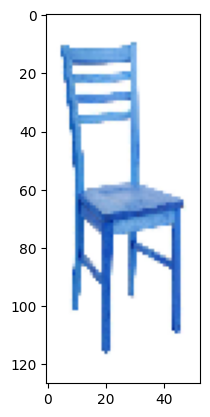

In [50]:
plt.imshow(new_chair_image)

In [51]:
cv2.imwrite('../images/new_chair.jpg', new_chair_image)

True

## Using Poisson blending to seamless merge chair onto room

In [52]:
resized_mask = np.ones((new_chair_image.shape[0]-10, new_chair_image.shape[1]), dtype='uint8')

In [53]:
resized_mask.shape

(117, 53)

In [54]:
mask255 = (resized_mask * 255).astype('uint8')
center = place_point
mask255.shape

(117, 53)

In [55]:
merged = cv2.seamlessClone(new_chair_image, img, mask255, center, cv2.MIXED_CLONE)

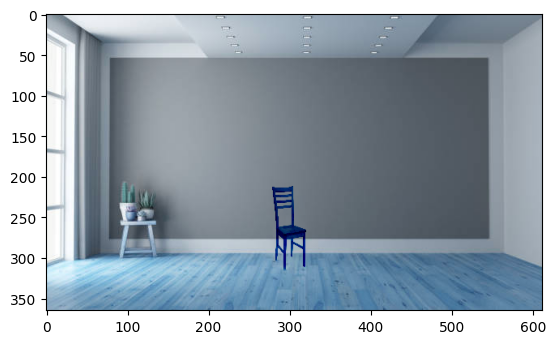

In [56]:
plt.imshow(merged)

In [57]:
cv2.imwrite("../images/cloned_img.jpg", merged)

True

Selecting point where to place furniture using mouse click

In [162]:
import time

In [176]:
selected_x = 0
selected_y = 0
done = False

In [171]:
clone = img.copy()

In [182]:
def select_point(event,x,y,flags,param):
    global selected_x,selected_y, done
    if event == cv2.EVENT_LBUTTONDOWN:
        cv2.circle(img,(x,y),10,(255,0,0),-1)
        selected_x,selected_y = x,y
        done= True

In [183]:
cv2.namedWindow('furniture_point')
cv2.setMouseCallback('furniture_point', select_point)

done = False
while True:
    time.sleep(0.5)
    cv2.imshow('furniture_point',img)
    if done:
        img = clone.copy()
        cv2.destroyAllWindows()
        break

    k = cv2.waitKey(20) & 0xFF
    if k == 27:
        break
    elif k == ord('a'):
        print (selected_x,selected_y)
    elif k == ord('r'):
        img = clone.copy()

In [181]:
cv2.destroyAllWindows()

In [184]:
selected_x, selected_y

(296, 214)

## Selecting object

In [33]:
from segment_anything import SamPredictor
predictor = SamPredictor(sam)

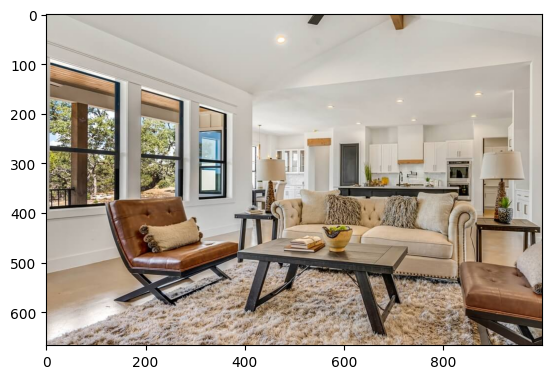

In [36]:
plt.imshow(img)

In [49]:
input_point = np.array([[410, 470], [650, 600]])
input_label = np.array([1, 1])

In [39]:
predictor.set_image(img)

In [76]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=False,
)

In [77]:
masks.shape

(1, 667, 1000)

In [78]:
type(masks)

numpy.ndarray

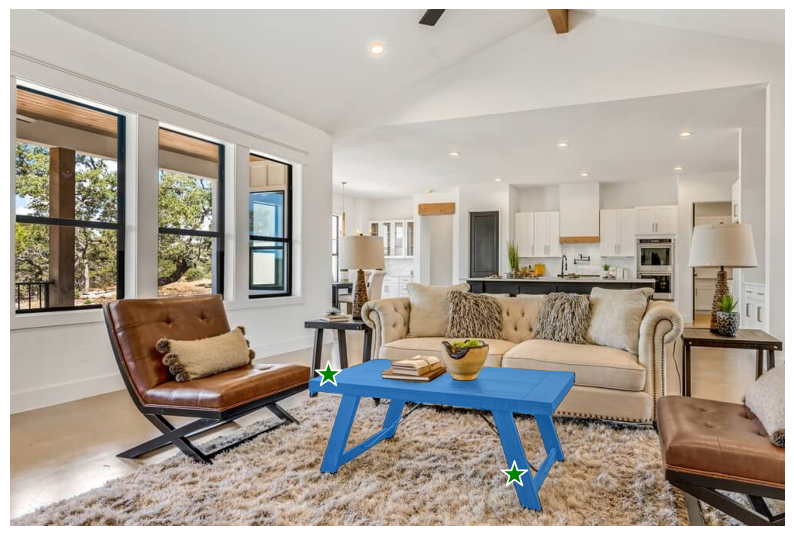

In [51]:
plt.figure(figsize=(10,10))
plt.imshow(img)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show() 

Mask or the specific table is highlighted

In [79]:
masks_array = np.array(masks, dtype=bool)

In [80]:
masks_array

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]],
      shape=(1, 667, 1000))

In [81]:
table_mask = masks_array[masks_array]

In [83]:
table_mask.shape

(22626,)